In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64

import healpy as hp
import jax.numpy as jnp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

## 1. Set up masks and psf

In [2]:
# mask
nside = 128
band_mask_range = 2.
r_outer = 25.
mask_ps = hp.ud_grade(np.load(f"../data/mask_3fgl_0p8deg.npy"), nside_out=nside) > 0
mask_roi = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=band_mask_range, mask_ring=True, inner=0, outer=r_outer, custom_mask=mask_ps)
mask_plane = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=25,)
normalization_mask = mask_plane
mask_outer = cm.make_mask_total(nside=nside, band_mask=False, mask_ring=True, inner=0, outer=25,)

# temp
nfw_template = NFWTemplate(nside=nside)
disk_template = LorimerDiskTemplate(nside=nside)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
# additional masks
indices = np.where(~normalization_mask)[0]
np.random.shuffle(indices)
indices = indices[:np.sum(~mask_roi)]

mask_random = np.ones_like(normalization_mask, dtype=bool)
mask_random[indices] = False

mask_random_ps = np.load(f"mask_random_ps.npy")
mask_loc = np.load(f"mask_loc.npy")

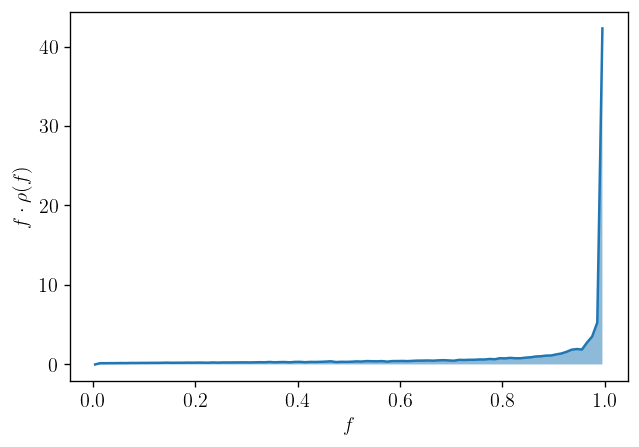

In [4]:
#psf_name = 'king'
psf_name = 'delta'
if psf_name == 'king':
    kp = KingPSF()
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = kp.psf_fermi_r, num_f_bins=30)
elif psf_name == 'delta':
    sigma = np.deg2rad(0.1) / 3
    psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = psf_r_func, num_f_bins=30)

df = f_ary[1] - f_ary[0]
plt.plot(f_ary, df_rho_div_f_ary/df*f_ary**2)
plt.fill_between(f_ary, df_rho_div_f_ary/df*f_ary**2, 0., alpha=0.5)
plt.ylabel(r'$f\cdot\rho(f)$')
plt.xlabel(r'$f$');

## scan ll

In [5]:
run_name = 'Sps_dsk_gce_nopscmask_deltapsf'
truth_dict = pickle.load(open(f'../outputs/ll_issue/{run_name}/truth.p', 'rb'))

# temp
temp_ps = {
    'gce' : nfw_template.get_NFW2_template(gamma=truth_dict['gamma_ps']),
    'dsk' : disk_template.get_template(zs=truth_dict['zs'], C=truth_dict['C']),
    'iso' : np.ones_like(mask_outer, dtype=float),
}
for k in temp_ps: # assume previous masks are not normalized
    temp_ps[k] /= jnp.mean(temp_ps[k][~normalization_mask])

# S over A
Sps_over_A_dict = {}
for k in ['dsk', 'gce', 'iso']:
    s_ary = np.logspace(-1., 2., 100)
    vd = truth_dict
    theta_tmp = np.array([1., vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['lambdas_'+k] * vd['sb1_'+k]])
    dnds_ary = dnds(s_ary, theta_tmp)
    Sps_over_A_dict[k] = np.mean(temp_ps[k][~normalization_mask]) * np.trapz(s_ary * dnds_ary, s_ary)

In [6]:
Sps_key = 'dsk'
Sps_s = np.linspace(0.5, 1.5, 50)
mask = normalization_mask
save_fn = f'../outputs/ll_issue/{run_name}/ll_ss_nm_unnorm.p'
include_ps_k = ['dsk', 'gce']

ll_ss = []
counts_arr = []
pt_sum_compressed = np.full_like(temp_ps['dsk'][~mask], 1e-10, dtype=np.float64)
npt_compressed = [np.array(temp_ps[k][~mask], dtype=np.float64) for k in include_ps_k]

for i_data in tqdm(range(50)):
    ll_s = []
    fermi_data = np.load(f'../outputs/ll_issue/{run_name}/counts_{i_data}.npy')[~mask].astype(np.int32)
    counts_arr.append(np.sum(fermi_data))
    for i, Sps in enumerate(Sps_s):
        A = {}
        for k in include_ps_k:
            A[k] = vd['Sps_'+k] / Sps_over_A_dict[k]
        A[Sps_key] = Sps / Sps_over_A_dict[k]
        theta = np.array([ [A[k], vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['sb1_'+k]*vd['lambdas_'+k]] for k in include_ps_k ], dtype=np.float64)
        ll = npll.log_like(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
        ll_s.append(ll)
    ll_ss.append(ll_s)
pickle.dump(ll_ss, open(save_fn, 'wb'))

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [14:12<00:00, 17.05s/it]


In [33]:
ll_ss = pickle.load(open(f'../outputs/ll_issue/{run_name}/ll_ss_nm.p', 'rb'))

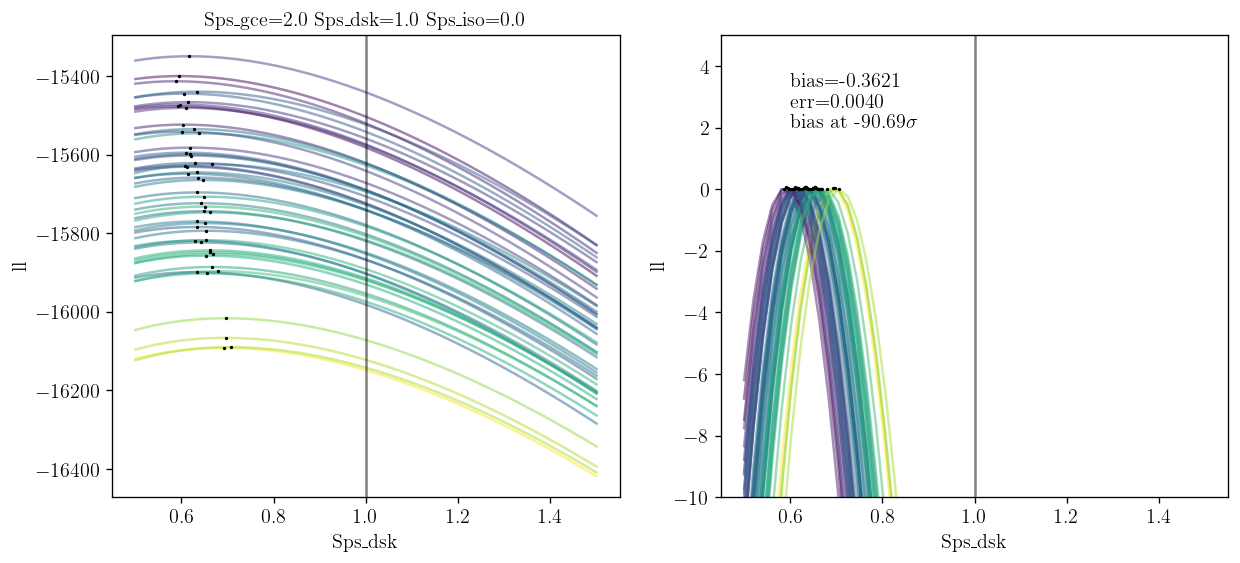

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []

for i in range(50):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

title_str = " ".join([f"Sps_{k}={vd['Sps_'+k]}" for k in ['gce', 'dsk', 'iso']])

ax = axs[0]
ax.axvline(truth_dict['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(title=title_str, xlabel="Sps_"+Sps_key, ylabel='ll')

ax = axs[1]
ax.axvline(truth_dict['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(xlabel="Sps_"+Sps_key, ylabel='ll')

bias = (np.mean(max_x_s) - vd['Sps_'+Sps_key])
err = np.std(max_x_s) / np.sqrt(len(max_x_s))
bias_sigma = bias/err

ax.text(0.6, 2, f"bias={bias:.4f}\nerr={err:.4f}\nbias at {bias_sigma:.2f}"+r"$\sigma$");

In [34]:
ll_ss = pickle.load(open('../outputs/justSps_nomask/ll_ss.p', 'rb'))
max_x_s = []
max_y_s = []

for i in range(50):
    rll = ll_ss[i]
    max_x, max_y = find_max_point(Sps_dsk_s, rll)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

In [35]:
(np.mean(max_x_s) - 1)

-0.038658730837494604

In [36]:
(np.mean(max_x_s) - 1)/np.std(max_x_s), np.std(max_x_s)

(-0.9240036112585844, 0.04183828977122458)

In [11]:
Sps_gce_s = np.linspace(1.5, 2.5, 50)
ll_ss = []
counts_arr = []

mask = normalization_mask

pt_sum_compressed = np.full_like(temp_ps_dsk[~mask], 1e-10, dtype=np.float64)
npt_compressed = [
    np.array(temp_ps_dsk[~mask], dtype=np.float64),
    np.array(temp_ps_gce[~mask], dtype=np.float64),
]

for i_data in tqdm(range(100)):
    ll_s = []
    fermi_data = np.load(f'../outputs/justSps/counts_{i_data}.npy')[~mask].astype(np.int32)
    counts_arr.append(np.sum(fermi_data))
    for i, Sps_gce in enumerate(Sps_gce_s):
        A_dsk = vd['Sps_dsk'] / Sps_over_A_dsk
        A_gce = Sps_gce / Sps_over_A_gce
        theta = np.array([
            [A_dsk, vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['sb1_dsk']*vd['lambdas_dsk']],
            [A_gce, vd['n1_gce'], vd['n2_gce'], vd['n3_gce'], vd['sb1_gce'], vd['sb1_gce']*vd['lambdas_gce']],
        ], dtype=np.float64)
        ll = npll.log_like(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

100%|██████████| 100/100 [02:45<00:00,  1.66s/it]


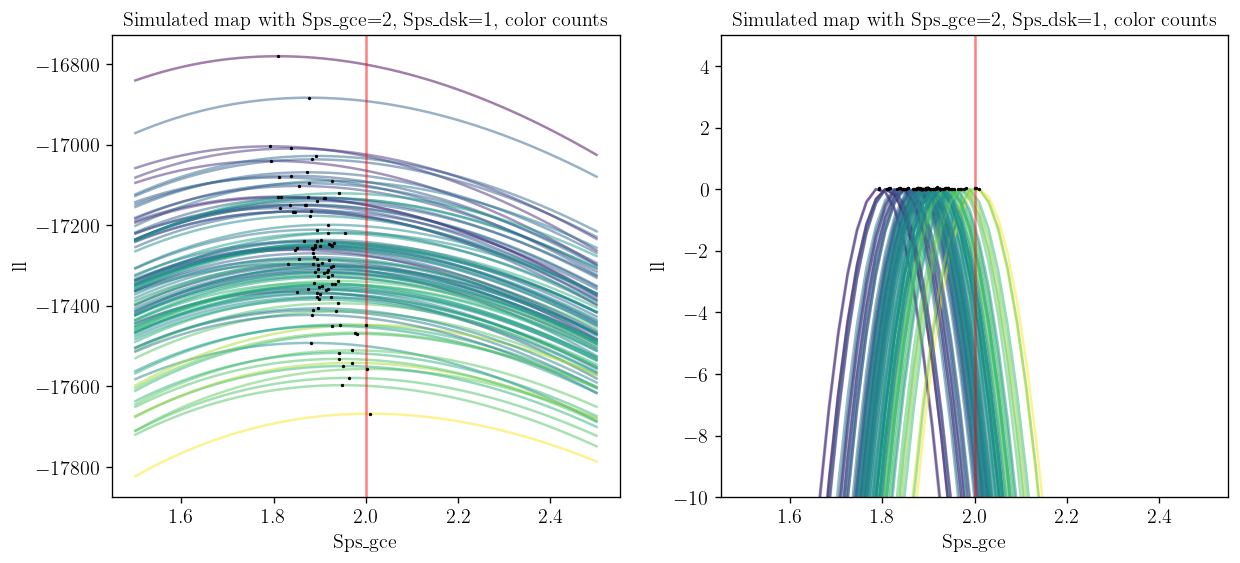

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []

for i in range(100):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_gce_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_gce_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_gce_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_gce_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

ax = axs[0]
ax.axvline(truth_dict['Sps_gce'], color='r', ls='-', alpha=0.5)
ax.set(title="Simulated map with Sps_gce=2, Sps_dsk=1, color~counts", xlabel="Sps_gce", ylabel='ll')

ax = axs[1]
ax.axvline(truth_dict['Sps_gce'], color='r', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(title="Simulated map with Sps_gce=2, Sps_dsk=1, color~counts", xlabel="Sps_gce", ylabel='ll');

## scan 1D

In [22]:
truth_dict = pickle.load(open('../outputs/Sps_dsk_nomask/truth.p', 'rb'))

temp_ps_gce = nfw_template.get_NFW2_template(gamma=truth_dict['gamma_ps'])
zs = truth_dict['zs']
C = truth_dict['C']
temp_ps_dsk = disk_template.get_template(zs=zs, C=C)

In [ ]:
kp = KingPSF()
psf_r_func = lambda r: kp.psf_fermi_r(r)
f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = psf_r_func)

In [23]:
sigma = np.deg2rad(0.1) / 3
psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)
f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = psf_r_func, num_f_bins=30)
print(df_rho_div_f_ary * f_ary**2 / (f_ary[1] - f_ary[0]))

[ 0.09394586  0.17427082  0.17877418  0.2021876   0.21271558  0.21211111
  0.22867379  0.24284878  0.25930064  0.27870436  0.28498085  0.31443905
  0.32717337  0.34165061  0.36812671  0.39944872  0.39961999  0.42242893
  0.472661    0.48799458  0.50351957  0.57486805  0.60931318  0.6581751
  0.79330602  0.89145299  1.06897792  1.41130353  2.10521332 15.48181379]


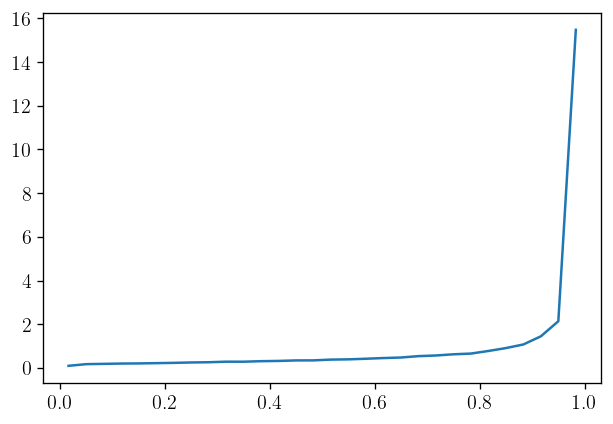

In [39]:
plt.plot(f_ary, df_rho_div_f_ary * f_ary**2 / (f_ary[1] - f_ary[0]))

In [26]:
# delta psf
rho = np.zeros_like(f_ary)
rho[-1] = 1./(f_ary[1] - f_ary[0]) * (1/0.49166)
df = f_ary[1] - f_ary[0]
df_rho_div_f_ary = df * rho / f_ary
print(np.trapz(df_rho_div_f_ary/df*f_ary**2, f_ary))

1.0000135595058948


In [24]:
# S over A
s_ary = np.logspace(-1., 2., 100)
vd = truth_dict
theta_tmp = np.array([1., vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['lambdas_dsk'] * vd['sb1_dsk']])
dnds_ary = dnds(s_ary, theta_tmp)
Sps_over_A = np.mean(temp_ps_dsk[~normalization_mask]) * np.trapz(s_ary * dnds_ary, s_ary)
print(np.mean(temp_ps_dsk[~normalization_mask]))
print(np.trapz(s_ary * dnds_ary, s_ary))
print(Sps_over_A)

0.8653843
130.74215613068424
113.142204


In [25]:
mask = mask_outer
save_fn = 'll_nptfit_nomask'
counts_dir = '../outputs/Sps_dsk_nomask'

pt_sum_compressed = np.full_like(temp_ps_dsk[~mask], 1e-10, dtype=np.float64)
npt_compressed = [np.array(temp_ps_dsk[~mask], dtype=np.float64)]

Sps_s = np.linspace(0.8, 1.2, 50)
ll_ss = []
counts_arr = []

for i_data in tqdm(range(50)):
    ll_s = []
    fermi_data = np.load(f'{counts_dir}/counts_{i_data}.npy')[~mask].astype(np.int32)
    counts_arr.append(np.sum(fermi_data))
    for i, Sps in enumerate(Sps_s):
        A = Sps / Sps_over_A
        theta = np.array([A, vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['sb1_dsk']*vd['lambdas_dsk']], dtype=np.float64)
        ll = npll.log_like(pt_sum_compressed, [theta], f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
        ll_s.append(ll)
    ll_ss.append(ll_s)
    
pickle.dump(ll_ss, open(f'{counts_dir}/{save_fn}.p', 'wb'))

100%|██████████| 50/50 [02:03<00:00,  2.47s/it]


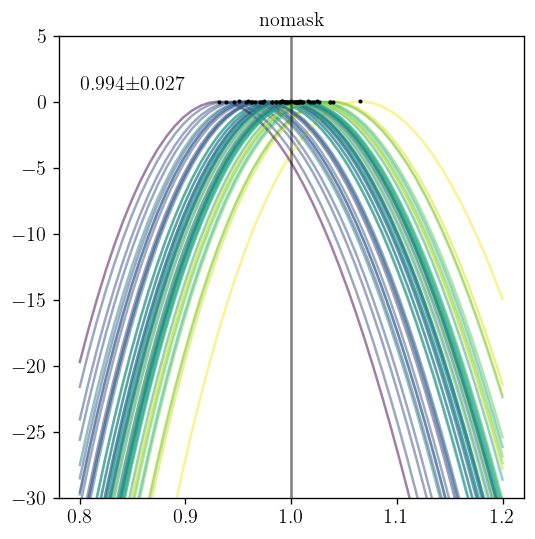

In [27]:
counts_dir = '../outputs/Sps_dsk_nomask'

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

for ax, k in zip([ax], ['nomask']):
    max_x_s = []
    max_y_s = []
    ll_ss = pickle.load(open(f'{counts_dir}/ll_nptfit_{k}.p', 'rb'))
    for i in range(50):
        rll = ll_ss[i] - np.max(ll_ss[i])
        color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
        color = cms['viridis'](color_x)
        ax.plot(Sps_s, rll, color=color, alpha=0.5)
        max_x, max_y = find_max_point(Sps_s, rll)
        max_x_s.append(max_x)
        max_y_s.append(max_y)
    ax.scatter(max_x_s, max_y_s, c='k', s=2, zorder=10)
    ax.text(0.8, 1, f'{np.mean(max_x_s):.3f}'+r'$\pm$'+f'{np.std(max_x_s):.3f}')
    ax.axvline(truth_dict['Sps_dsk'], color='k', ls='-', alpha=0.5)
    ax.set(ylim=(-30, 5), title=k)

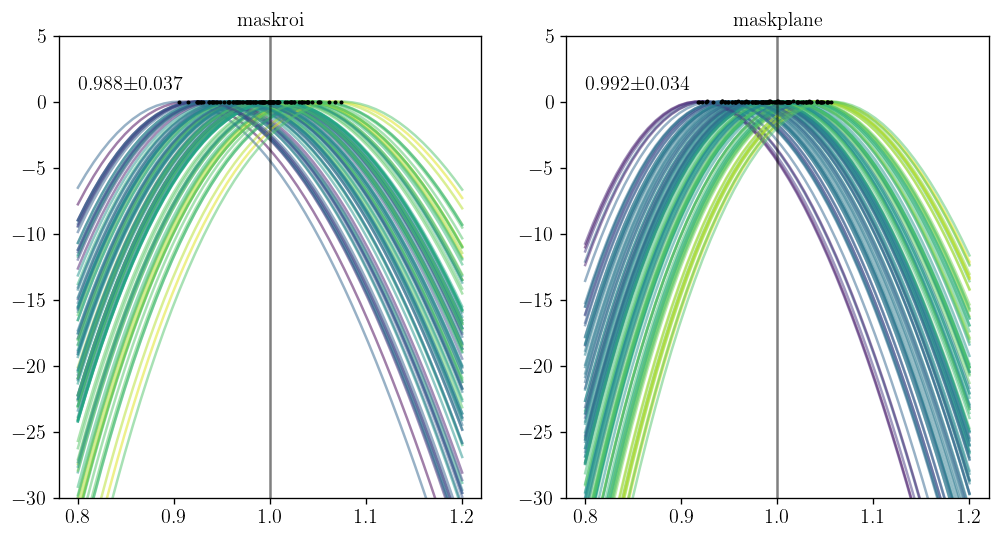

In [ ]:
counts_dir = '../outputs/Sps_dsk_deltapsf'

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for ax, k in zip(axs, ['maskroi', 'maskplane']):
    max_x_s = []
    max_y_s = []
    ll_ss = pickle.load(open(f'{counts_dir}/ll_nptfit_{k}_deltapsf.p', 'rb'))
    for i in range(100):
        rll = ll_ss[i] - np.max(ll_ss[i])
        color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
        color = cms['viridis'](color_x)
        ax.plot(Sps_s, rll, color=color, alpha=0.5)
        max_x, max_y = find_max_point(Sps_s, rll)
        max_x_s.append(max_x)
        max_y_s.append(max_y)
    ax.scatter(max_x_s, max_y_s, c='k', s=2, zorder=10)
    ax.text(0.8, 1, f'{np.mean(max_x_s):.3f}'+r'$\pm$'+f'{np.std(max_x_s):.3f}')
    ax.axvline(truth_dict['Sps_dsk'], color='k', ls='-', alpha=0.5)
    ax.set(ylim=(-30, 5), title=k)